Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

CSV File

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/bloomingcodeby-iffath/MU_Canteen_Rush_Predictor/refs/heads/main/canteen_rush_data.csv"
df = pd.read_csv(url)
# df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print(df.head())

   Time  Day  Lunch_Time Weather  Students Rush_Level
0     9  Mon           0   Sunny        20     Medium
1    10  Mon           0   Sunny        25     Medium
2    11  Mon           1   Sunny        40       High
3    12  Mon           1   Sunny        70       High
4    13  Mon           1   Sunny        85       High


In [3]:
print(df.info())
print(df.isnull().sum())
print(df["Day"].unique())
print(df["Weather"].unique())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Time        108 non-null    int64 
 1   Day         108 non-null    object
 2   Lunch_Time  108 non-null    int64 
 3   Weather     108 non-null    object
 4   Students    108 non-null    int64 
 5   Rush_Level  108 non-null    object
dtypes: int64(3), object(3)
memory usage: 5.2+ KB
None
Time          0
Day           0
Lunch_Time    0
Weather       0
Students      0
Rush_Level    0
dtype: int64
['Mon' 'Tue' 'Wed' 'Thu' 'Sun']
['Sunny' 'Rainy' 'Cloudy' 'Windy']


Exploratory Data Analysis (EDA + Graph)

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt


1)Rush Level vs Students & Time vs Students

C:\Users\IFFATH\AppData\Local\Temp\ipykernel_13724\3061698411.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Rush_Level', y='Students', data=df, palette=colors)


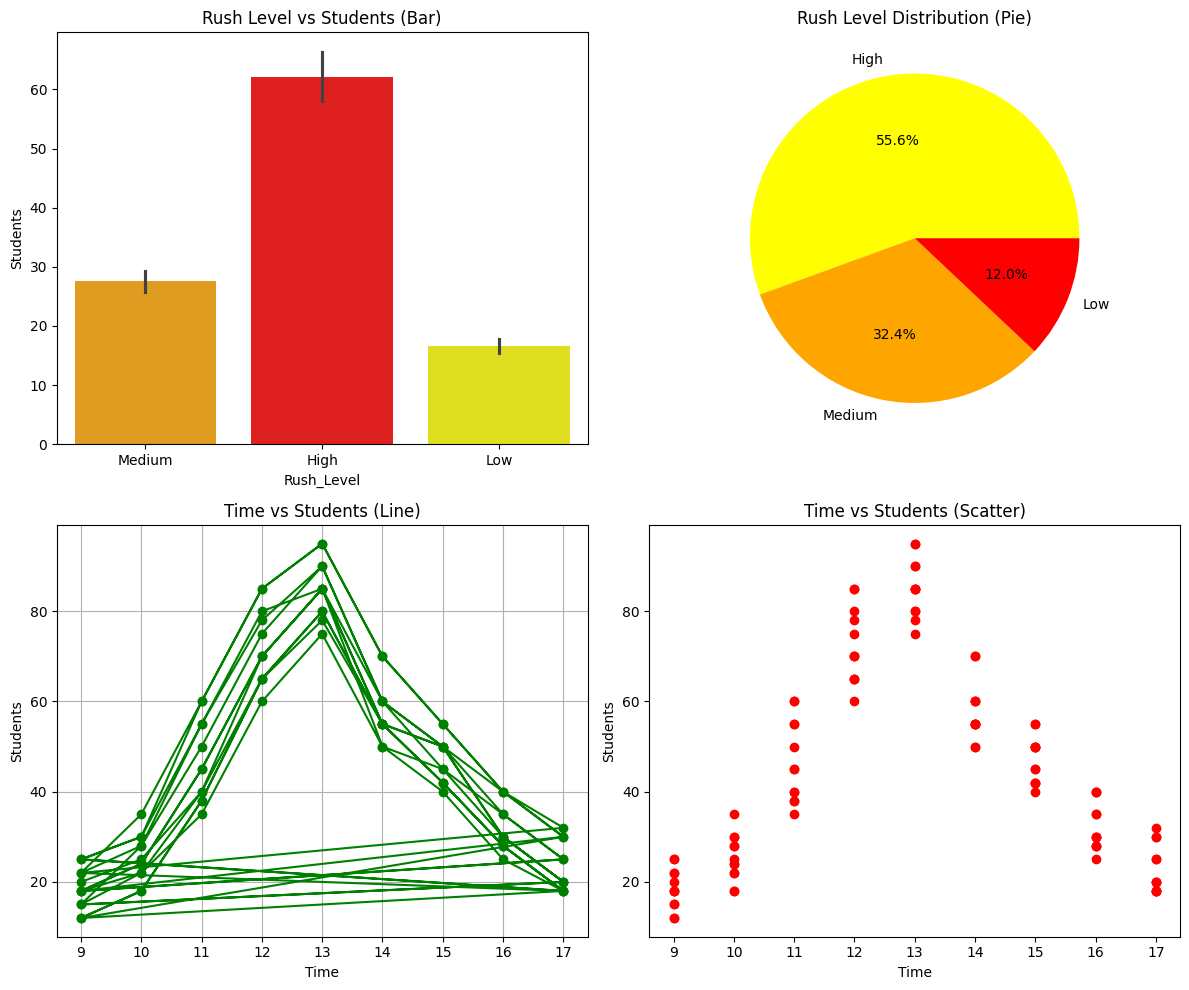

In [5]:
plt.figure(figsize=(12,10))
colors = {'Low':'yellow', 'Medium':'orange', 'High':'red'}
# a) Bar plot
plt.subplot(2,2,1)
sns.barplot(x='Rush_Level', y='Students', data=df, palette=colors)
plt.title('Rush Level vs Students (Bar)')

# b) Pie chart
plt.subplot(2,2,2)
rush_counts = df['Rush_Level'].value_counts()
plt.pie(rush_counts, labels=rush_counts.index, autopct='%1.1f%%', colors=['yellow','orange','red'])
plt.title('Rush Level Distribution (Pie)')

# c) Line plot
plt.subplot(2,2,3)
plt.plot(df['Time'], df['Students'], marker='o', color='green')
plt.title('Time vs Students (Line)')
plt.xlabel('Time')
plt.ylabel('Students')
plt.grid(True)

# d) Scatter plot
plt.subplot(2,2,4)
plt.scatter(df['Time'], df['Students'], color='red')
plt.title('Time vs Students (Scatter)')
plt.xlabel('Time')
plt.ylabel('Students')

plt.tight_layout()
plt.show()

2)Weather vs Students  & Lunch_Time vs Students

C:\Users\IFFATH\AppData\Local\Temp\ipykernel_13724\608697539.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Weather', y='Students', data=df, palette='pastel')
C:\Users\IFFATH\AppData\Local\Temp\ipykernel_13724\608697539.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weather', y='Students', data=df, estimator=lambda x: sum(x)/len(x), palette='coolwarm')
C:\Users\IFFATH\AppData\Local\Temp\ipykernel_13724\608697539.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Lunch_Time', y='Students', data=df, palette='pastel')


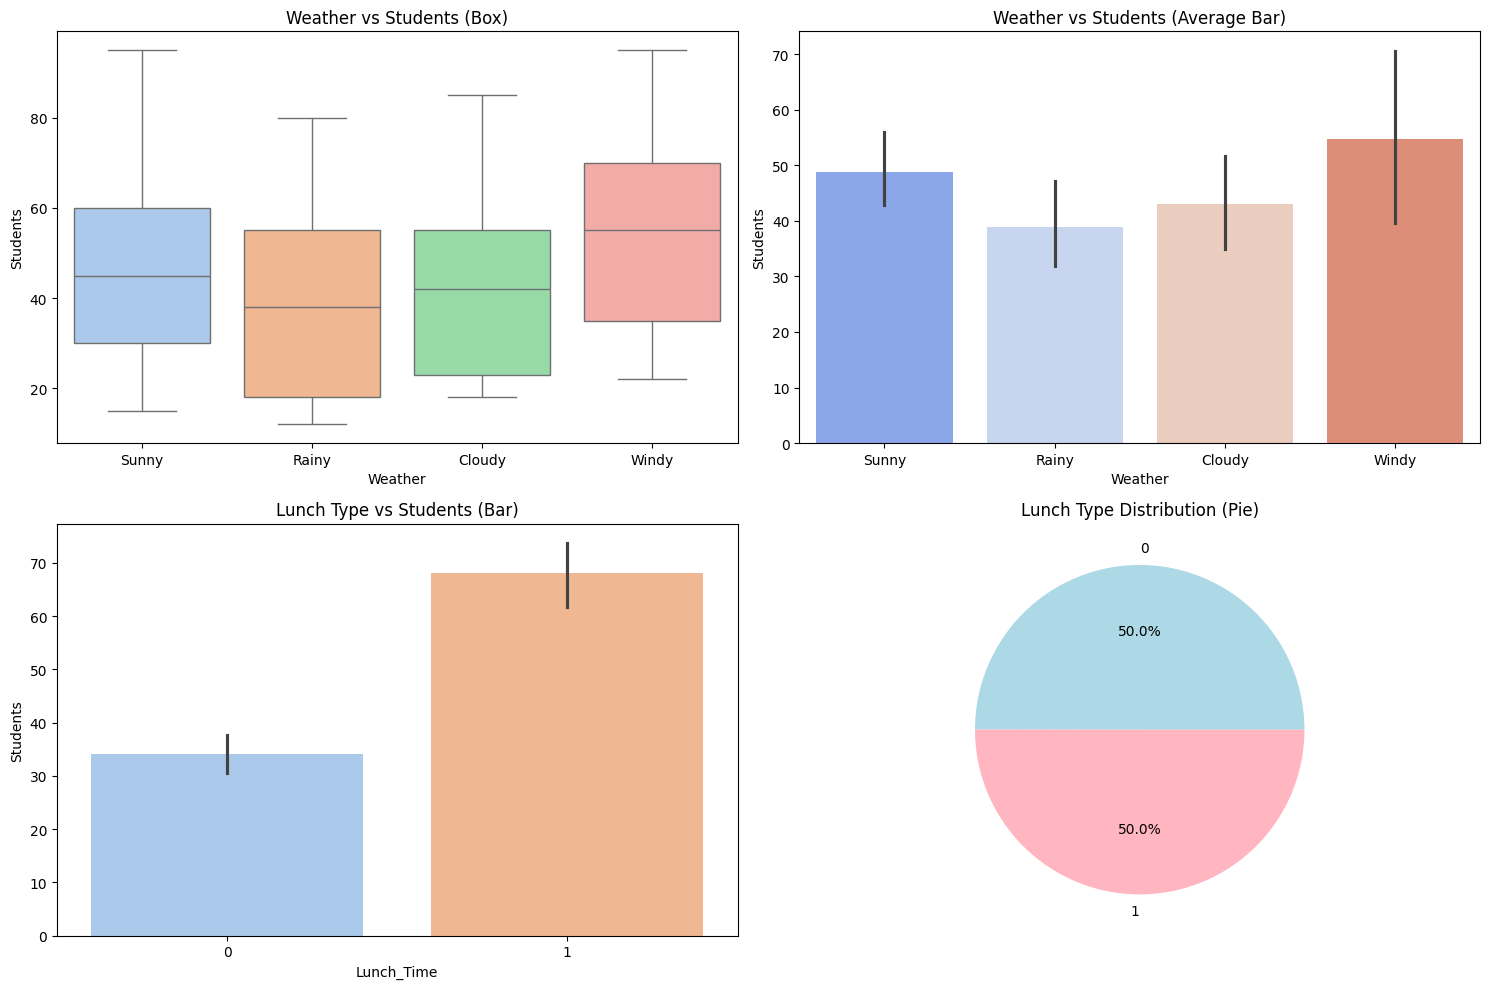

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

# a) Box plot
plt.subplot(2,2,1)
sns.boxplot(x='Weather', y='Students', data=df, palette='pastel')
plt.title('Weather vs Students (Box)')

# b) Average Bar plot
plt.subplot(2,2,2)
sns.barplot(x='Weather', y='Students', data=df, estimator=lambda x: sum(x)/len(x), palette='coolwarm')
plt.title('Weather vs Students (Average Bar)')

plt.tight_layout()

# c) Bar plot
plt.subplot(2,2,3)
sns.barplot(x='Lunch_Time', y='Students', data=df, palette='pastel')
plt.title('Lunch Time vs Students (Bar)')

# d) Pie chart
plt.subplot(2,2,4)
lunch_counts = df.groupby('Lunch_Time')['Students'].sum()
plt.pie(lunch_counts, labels=lunch_counts.index, autopct='%1.1f%%', colors=['lightblue','lightpink'])
plt.title('Lunch Time Distribution (Pie)')

plt.tight_layout()
plt.show()



plt.show()

5)Time vs Rush Level

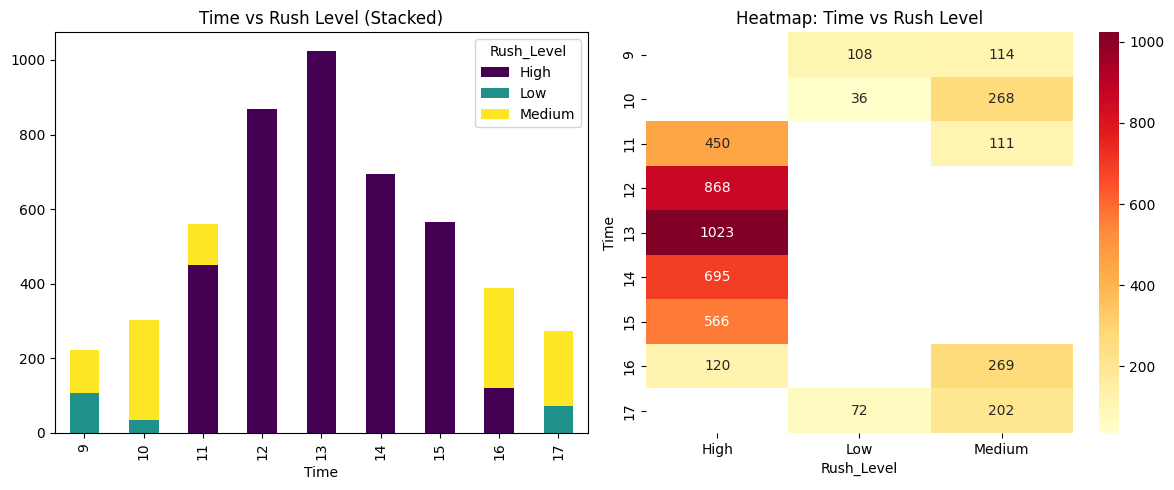

In [7]:
plt.figure(figsize=(12,5))

# a) Stacked Bar chart
plt.subplot(1,2,1)
rush_time = df.groupby(['Time', 'Rush_Level'])['Students'].sum().unstack()
rush_time.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='viridis')
plt.title('Time vs Rush Level (Stacked)')

# b) Heatmap
plt.subplot(1,2,2)
rush_heatmap = df.pivot_table(index='Time', columns='Rush_Level', values='Students', aggfunc='sum')
sns.heatmap(rush_heatmap, annot=True, fmt=".0f", cmap='YlOrRd', ax=plt.gca())
plt.title('Heatmap: Time vs Rush Level')

plt.tight_layout()
plt.show()

Multivariate Analysis

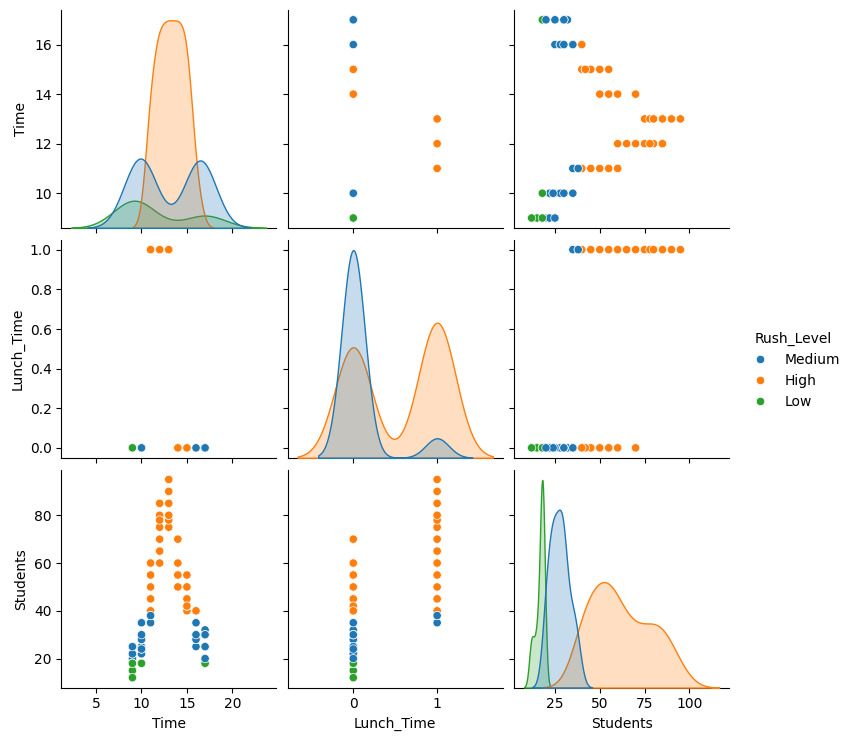

In [8]:
sns.pairplot(df, hue='Rush_Level')
plt.show()

Correlation





Target correlations

Students → Rush_Level_Encoded = 0.96 ✅

Very strong positive correlation. Intuition matches reality: more students → higher rush.

Lunch_Time → Rush_Level_Encoded = 0.90

High correlation — rush is heavily concentrated around lunch hours.

Time → Rush_Level_Encoded = 0.39

Moderate correlation — time of day matters, but not as strongly as lunch period.

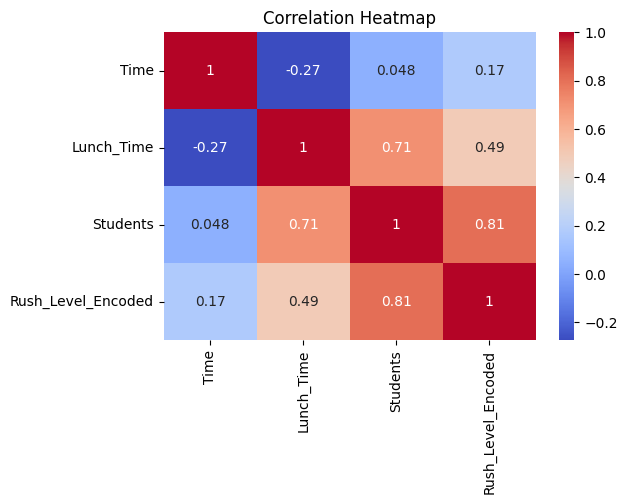

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Encode only target
rush_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Rush_Level_Encoded'] = df['Rush_Level'].map(rush_mapping)
# df['Rush_Level_Encoded'] = le.fit_transform(df['Rush_Level'])

# Select ONLY numeric columns
numeric_df = df[['Time',
                 'Lunch_Time',
                 'Students',
                 'Rush_Level_Encoded']]

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# **Data preprocessing**

Encoding (Day, Weather)


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Day encode
df['Day_Encoded'] = le.fit_transform(df['Day'])

# Weather encode
df['Weather_Encoded'] = le.fit_transform(df['Weather'])

Feature Selection (X & y)

In [11]:
# Input features (X)
X = df[['Time', 'Lunch_Time', 'Day_Encoded', 'Weather_Encoded']]

# Target (y)
y = df['Students']

Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (86, 4)
Test size: (22, 4)


# **Model Building**

Linear Regression

In [13]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


Random Forest

In [14]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

import pickle


# Model save
pickle.dump(rf, open("rf_model.pkl", "wb"))

print("Model successfully saved as rf_model.pkl")

Model successfully saved as rf_model.pkl


**Actual vs Predicted Graph**

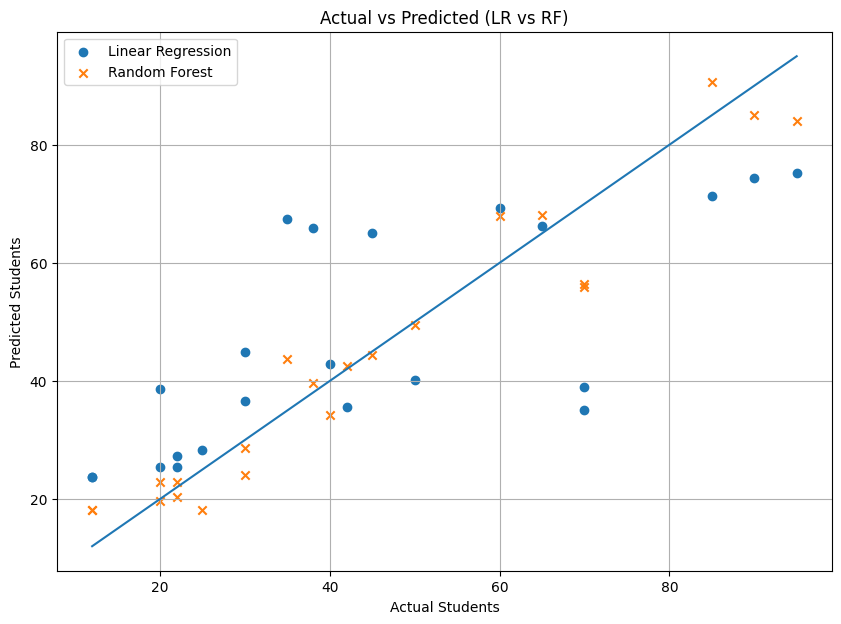

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

# Linear Regression
plt.scatter(y_test, y_pred_lr, label='Linear Regression', marker='o')

# Random Forest
plt.scatter(y_test, y_pred_rf, label='Random Forest', marker='x')

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual Students")
plt.ylabel("Predicted Students")
plt.title("Actual vs Predicted (LR vs RF)")
plt.legend()
plt.grid(True)

plt.show()

**Error Distribution Graph**

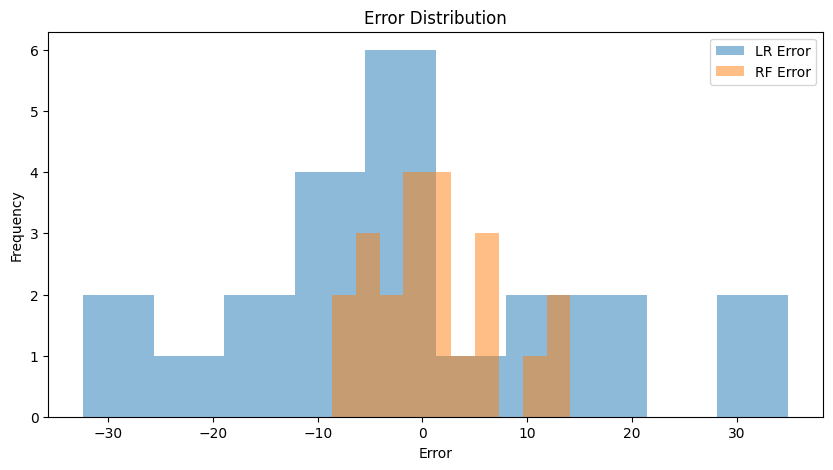

In [16]:
errors_lr = y_test - y_pred_lr
errors_rf = y_test - y_pred_rf

plt.figure(figsize=(10,5))

plt.hist(errors_lr, bins=10, alpha=0.5, label='LR Error')
plt.hist(errors_rf, bins=10, alpha=0.5, label='RF Error')

plt.title('Error Distribution')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.legend()

plt.show()

**Residual Plot**

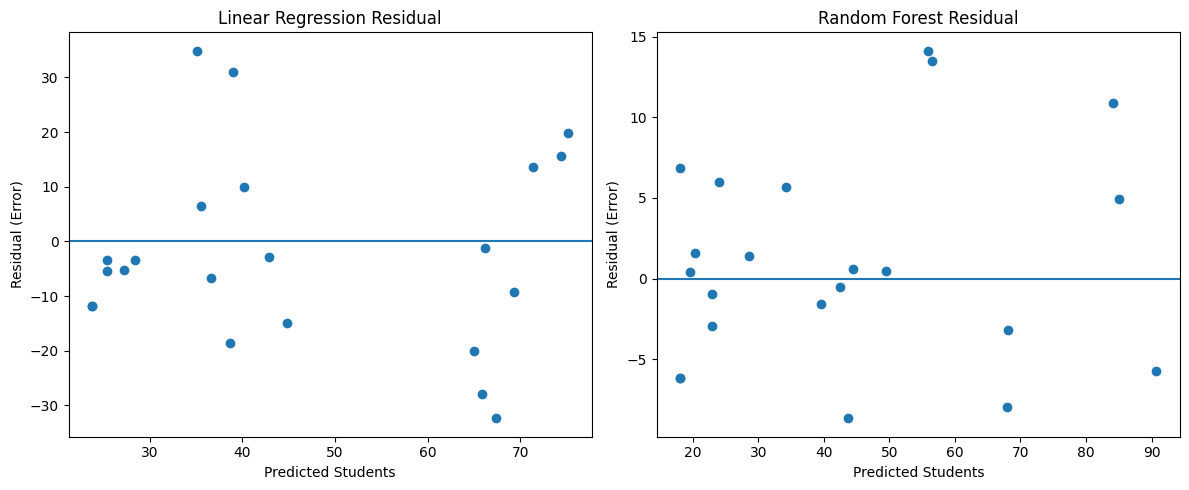

In [17]:
import matplotlib.pyplot as plt

# Residuals calculate
residuals_lr = y_test - y_pred_lr
residuals_rf = y_test - y_pred_rf

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# 🔹 Linear Regression Residual Plot
axes[0].scatter(y_pred_lr, residuals_lr)
axes[0].axhline(y=0)
axes[0].set_title("Linear Regression Residual")
axes[0].set_xlabel("Predicted Students")
axes[0].set_ylabel("Residual (Error)")

# 🔹 Random Forest Residual Plot
axes[1].scatter(y_pred_rf, residuals_rf)
axes[1].axhline(y=0)
axes[1].set_title("Random Forest Residual")
axes[1].set_xlabel("Predicted Students")
axes[1].set_ylabel("Residual (Error)")

plt.tight_layout()
plt.show()

# **Model Comparison**

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

Comparison Table

In [19]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'MSE': [mse_lr, mse_rf],
    'R2 Score': [r2_lr, r2_rf]
})

print(comparison)

               Model        MAE         MSE  R2 Score
0  Linear Regression  13.911363  292.245536  0.525066
1      Random Forest   5.009341   41.552838  0.932472


**Model Comparison Bar Chart**

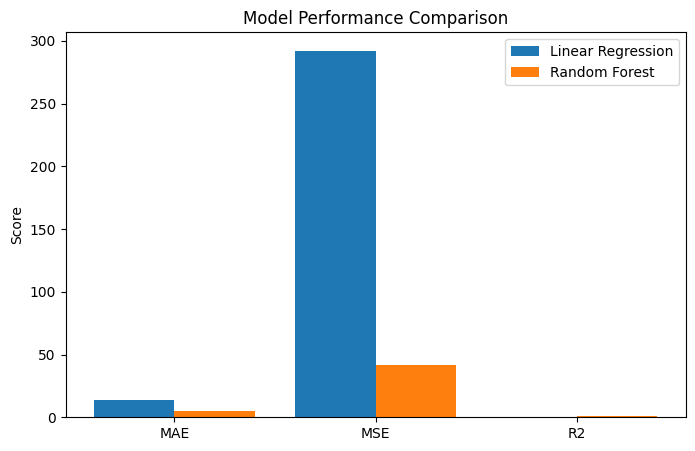

In [20]:
import numpy as np
import matplotlib.pyplot as plt

labels = ['MAE', 'MSE', 'R2']
lr_values = [mae_lr, mse_lr, r2_lr]
rf_values = [mae_rf, mse_rf, r2_rf]

x = np.arange(len(labels))

plt.figure(figsize=(8,5))

plt.bar(x - 0.2, lr_values, width=0.4, label='Linear Regression')
plt.bar(x + 0.2, rf_values, width=0.4, label='Random Forest')

plt.xticks(x, labels)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.legend()

plt.show()

# **Rush Level**

In [21]:
def get_rush_level(students):
    if students < 20:
        return 'Low'
    elif students < 40:
        return 'Medium'
    else:
        return 'High'

In [22]:
df_results = pd.DataFrame({
    'Actual_Students': y_test,
    'Predicted_LR': y_pred_lr,
    'Predicted_RF': y_pred_rf
})

df_results['Rush_LR'] = df_results['Predicted_LR'].apply(get_rush_level)
df_results['Rush_RF'] = df_results['Predicted_RF'].apply(get_rush_level)

print(df_results.head())

    Actual_Students  Predicted_LR  Predicted_RF Rush_LR Rush_RF
77               70     38.977216     56.486667  Medium    High
10               22     27.249366     20.420000  Medium  Medium
4                85     71.326031     90.706667    High    High
83               38     65.840434     39.593333    High  Medium
62               20     38.604605     19.601833  Medium     Low


**Predicted Students → Rush Level Visualization**

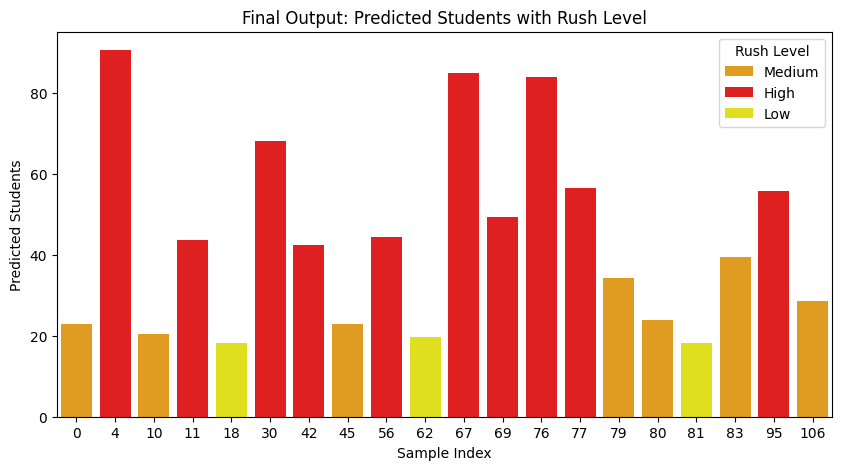

In [23]:
plt.figure(figsize=(10,5))

# predicted RF use korbo (best model)
sns.barplot(
    x=df_results.index[:20],
    y=df_results['Predicted_RF'][:20],
    hue=df_results['Rush_RF'][:20],
    palette={'Low':'yellow','Medium':'orange','High':'red'}
)

plt.title("Final Output: Predicted Students with Rush Level")
plt.xlabel("Sample Index")
plt.ylabel("Predicted Students")
plt.legend(title="Rush Level")

plt.show()